# **NOTEBOOK 4: Decision Tree & Random Forest Models**

In [18]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error, median_absolute_error
import seaborn as sns
from matplotlib import pyplot as plt

## Load Dataset

In [179]:
def load_dataset():
    file_path = Path.home() / 'Documents/IDX Internship/Raw Data'
    
    # all 30 datasets
    files = [
        file_path / 'CRMLSSold20220101_20231231_filled.csv', file_path / 'CRMLSSold202401_filled.csv',
        file_path / 'CRMLSSold202402_filled.csv', file_path / 'CRMLSSold202403_filled.csv',
        file_path / 'CRMLSSold202404_filled.csv', file_path / 'CRMLSSold202405_filled.csv',
        file_path / 'CRMLSSold202406_filled.csv', file_path / 'CRMLSSold202407_filled.csv',
        file_path / 'CRMLSSold202408.csv', file_path / 'CRMLSSold202409.csv',
        file_path / 'CRMLSSold202410.csv', file_path / 'CRMLSSold202411.csv',
        file_path / 'CRMLSSold202412.csv', file_path / 'CRMLSSold202501_filled.csv',
        file_path / 'CRMLSSold202502.csv', file_path / 'CRMLSSold202503.csv',
        file_path / 'CRMLSSold202504.csv', file_path / 'CRMLSSold202505.csv',
        file_path / 'CRMLSSold202506.csv', file_path / 'CRMLSSold202507.csv',
        file_path / 'CRMLSSold202508.csv', file_path / 'CRMLSSold202509.csv',
        file_path / 'CRMLSSold202510.csv', file_path / 'CRMLSSold202511.csv',
        file_path / 'CRMLSSold202512.csv', file_path / 'CRMLSSold202601.csv',
        file_path / 'CRMLSSold202602.csv', file_path / 'CRMLSSold202603.csv',
        file_path / 'CRMLSSold202604.csv', file_path / 'CRMLSSold202605.csv',
    ]
    
    # dtype to str to handle mixed value types for some columns
    data_dfs = [pd.read_csv(f, dtype={'WaterfrontYN': str, 'PostalCode': str, 'latfilled': str, 'lonfilled': str,
                                      'ElementarySchool': str, 'BuilderName': str, 'CoBuyerAgentFirstName': str,
                                      'PoolPrivateYN': str}) for f in files]
    df = pd.concat(data_dfs, ignore_index=True)

    return df

In [182]:
init_df = load_dataset()
init_df.head()

,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled,BuyerAgentAOR,ListAgentAOR
0,"Carpet,Wood",True,NaN,NaN,True,98000.0,556366533,michellefsellsoc@gmail.com,2022-02-25,95000.0,...,0.0,ABC Unified,92708,0.0,NaN,NaN,False,False,NaN,NaN
1,NaN,False,NaN,NaN,False,1200.0,556366530,dineshcalre@gmail.com,2022-02-19,1200.0,...,1.0,Apple Valley Unified,92308,0.0,43000.0,NaN,False,False,NaN,NaN
2,NaN,True,NaN,NaN,False,1100000.0,556366044,cindydavishomes@gmail.com,2022-04-15,1100000.0,...,1.0,Solana Beach,92075,370.0,NaN,NaN,False,False,NaN,NaN
3,NaN,True,NaN,NaN,False,2499999.0,556365765,bryanmeathe@gmail.com,2022-01-04,2499999.0,...,2.0,Carlsbad Unified,92008,140.0,13376.0,NaN,False,False,NaN,NaN
4,"Carpet,Tile",NaN,NaN,NaN,NaN,598888.0,556365290,steven@westsideres.com,2022-01-12,640000.0,...,1.0,Other,95111,300.0,2738.0,NaN,False,False,NaN,NaN


<Axes: xlabel='ClosePrice', ylabel='Density'>

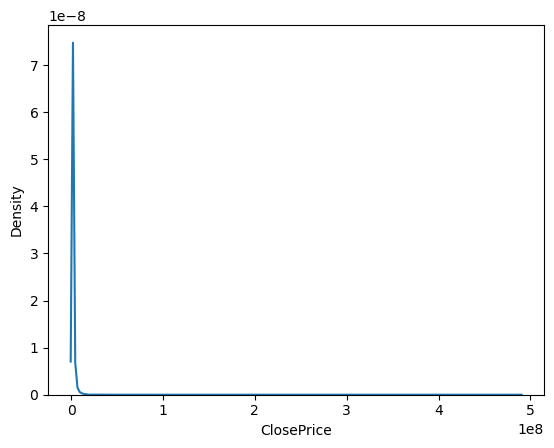

In [240]:
sns.kdeplot(data=init_df[init_df['ClosePrice'] < 500000000]['ClosePrice'])

## Data Preprocessing

In [235]:
def preprocessing(encode_loc=True):

    # load dataset
    df = load_dataset()
    
    # restrict analysis to residential and single family
    df = df[
        (df['PropertyType'] == 'Residential') &
        (df['PropertySubType'] == 'SingleFamilyResidence')].copy()

    # convert CloseDate to datetime dtype
    df['CloseDate'] = pd.to_datetime(df['CloseDate'])


    preprocessed_df = df.copy()
    

    ####################
    ### drop columns ###
    ####################
    
    # drop columns not known at prediction time
    drop_cols = ['ListPrice', 'DaysOnMarket', 'OriginalListPrice']
    preprocessed_df = preprocessed_df.drop(columns=drop_cols)

    # count missing values
    missing = pd.DataFrame({
        'Total Missing Values': preprocessed_df.isnull().sum(),
        'Proportion Missing': preprocessed_df.isnull().mean()
    })

    # drop column if null rate above 50%
    threshold = 0.5
    null_50 = missing[missing['Proportion Missing'] > threshold].index.tolist()
    preprocessed_df = preprocessed_df.drop(columns=null_50)

    # drop columns with no plausible relationship to ClosePrice
    unrelated = ['ContractStatusChangeDate', 'MlsStatus', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'ListingId',
                 'PurchaseContractDate', 'ListingContractDate', 'ListAgentEmail', 'ListOfficeName', 'BuyerOfficeName',
                 'ListingKey', 'ListingKeyNumeric', 'ListAgentFirstName', 'ListAgentLastName', 'StreetNumberNumeric',
                 'ListAgentFullName', 'BuyerAgentMlsId', 'BuyerOfficeAOR', 'BuyerAgentAOR', 'ListAgentAOR',
                 'UnparsedAddress']
    preprocessed_df = preprocessed_df.drop(columns=unrelated)

    # drop location variables (redundant due to Latitude and Longitude)
    preprocessed_df = preprocessed_df.drop(columns=['MLSAreaMajor', 'PostalCode'])
    

    ###################################
    ### convert unreasonable values ###
    ###################################

    # convert impossible coordinates to NaN
    invalid_coords = (
        (preprocessed_df['Latitude'] < -90) | (preprocessed_df['Latitude'] > 90) |
        (preprocessed_df['Longitude'] < -180) | (preprocessed_df['Longitude'] > 180) |
        (preprocessed_df['Latitude'] == 0) | (preprocessed_df['Longitude'] == 0)
    )
    preprocessed_df.loc[invalid_coords, ['Latitude','Longitude']] = np.nan

    # remove LivingArea values of 0
    preprocessed_df.loc[preprocessed_df['LivingArea'] <= 0, 'LivingArea'] = np.nan

    # remove ParkingTotal values less than 0 and greater than 100
    preprocessed_df.loc[preprocessed_df['ParkingTotal'] < 0, 'ParkingTotal'] = np.nan
    preprocessed_df.loc[preprocessed_df['ParkingTotal'] > 100, 'ParkingTotal'] = np.nan


    # drop rows with missing values for target variable and other important features with very little null values
    preprocessed_df = preprocessed_df.dropna(subset=['ClosePrice', 'LivingArea'])
    

    #######################
    ### fill NaN values ###
    #######################

    # fill values with less than 50% null rate
    # sentinel fill
    preprocessed_df['ParkingTotal'] = preprocessed_df['ParkingTotal'].fillna(0)
    preprocessed_df['GarageSpaces'] = preprocessed_df['GarageSpaces'].fillna(0)
    preprocessed_df['MainLevelBedrooms'] = preprocessed_df['MainLevelBedrooms'].fillna(0)
    
    # median fill
    for col in ['LotSizeSquareFeet', 'YearBuilt', 'Stories', 'Latitude', 'Longitude', 'BedroomsTotal',
                'BathroomsTotalInteger']:
        preprocessed_df[col] = preprocessed_df[col].fillna(preprocessed_df[col].median())

    # create binary has_hoa feature from AssociationFee
    preprocessed_df['AssociationFee'] = preprocessed_df['AssociationFee'].fillna(0)
    preprocessed_df["has_hoa"] = (preprocessed_df["AssociationFee"] > 0).astype(int)

    # create binary has_garage feature from GarageSpaces
    preprocessed_df['GarageSpaces'] = preprocessed_df['GarageSpaces'].fillna(0)
    preprocessed_df['has_garage'] = (preprocessed_df['GarageSpaces'] > 0).astype(int)
    preprocessed_df = preprocessed_df.drop(columns=['GarageSpaces'])
    
    # drop features with zero variance
    preprocessed_df = preprocessed_df.drop(columns=['PropertyType', 'PropertySubType'])

    # keep only one area column (LotSizeSquareFeet)
    preprocessed_df = preprocessed_df.drop(columns=['LotSizeArea', 'LotSizeAcres'])

    # fill null values for certain bool values with False
    for col in ['ViewYN', 'PoolPrivateYN', 'AttachedGarageYN', 'FireplaceYN', 'NewConstructionYN']:
        preprocessed_df[col] = preprocessed_df[col].astype(bool)
        preprocessed_df[col] = preprocessed_df[col].fillna(False).astype(int)

    # fill missing values for certain categorical variables with 'Unknown'
    for col in ['Flooring', 'HighSchoolDistrict', 'Levels', 'City']:
        preprocessed_df[col] = preprocessed_df[col].fillna('Unknown')

    # replace StateOrProvince (almost no variance) with binary InCalifornia variable
    preprocessed_df["InCalifornia"] = (preprocessed_df["StateOrProvince"] == "CA").astype(int)
    preprocessed_df = preprocessed_df.drop(columns=['StateOrProvince'])
    
    # fill missing value for CountyOrParish with mode
    preprocessed_df['CountyOrParish'] = preprocessed_df['CountyOrParish'].fillna(
        preprocessed_df['CountyOrParish'].mode()[0]
    )


    ####################################
    ### encode categorical variables ###
    ####################################

    # multi-label encode Flooring feature
    preprocessed_df['Flooring_SeeRemarks'] = (preprocessed_df['Flooring'].str.contains('SeeRemarks').astype(int))
    preprocessed_df['Flooring'] = (preprocessed_df['Flooring'].str.replace('SeeRemarks,?', '', regex=True))
    flooring_dummies = (preprocessed_df['Flooring'].str.get_dummies(sep=','))
    
    preprocessed_df = pd.concat(
        [preprocessed_df.drop(columns=['Flooring']), flooring_dummies.add_prefix('Flooring_')], axis=1)

    # multi-label encode Levels
    # create multi-label dummy variables
    levels_dummies = (preprocessed_df['Levels'].str.get_dummies(sep=','))
    levels_dummies = levels_dummies.add_prefix('Levels_') # add prefix
    
    preprocessed_df = pd.concat([preprocessed_df.drop(columns=['Levels']),levels_dummies],axis=1)


    if encode_loc:
        
        # one-hot encode CountyOrParish
        preprocessed_df['CountyOrParish'] = (preprocessed_df['CountyOrParish'].str.title()) # standard capitalization
        preprocessed_df['CountyOrParish'] = (preprocessed_df['CountyOrParish'].replace(
            ['Foreign Country', 'Other County', 'Other State', 'Other'], 'Other')) # replace non-counties with 'Other'
        preprocessed_df = pd.get_dummies(preprocessed_df, columns=['CountyOrParish'], drop_first=True, dtype='int8')
    
        # group cities with less than 500 entires and one-hot encode City
        city_counts = preprocessed_df['City'].value_counts()
        rare_cities = city_counts[city_counts < 500].index
        preprocessed_df['City'] = (preprocessed_df['City'].replace(rare_cities, 'Other'))
        preprocessed_df = pd.get_dummies(preprocessed_df, columns=['City'], drop_first=True, dtype='int8')
    
        # group districts with less than 100 entries and one-hot encode HighSchoolDistrict
        district_counts = preprocessed_df['HighSchoolDistrict'].value_counts()
        rare_districts = district_counts[district_counts < 100].index
        preprocessed_df['HighSchoolDistrict'] = (preprocessed_df['HighSchoolDistrict'].replace(rare_districts, 'Other'))
        preprocessed_df = pd.get_dummies(preprocessed_df, columns=['HighSchoolDistrict'], drop_first=True, dtype='int8')

    else:
        preprocessed_df = preprocessed_df.drop(columns=['CountyOrParish', 'City', 'HighSchoolDistrict'])
    

    return preprocessed_df


In [88]:
preprocessed_df = preprocessing()
preprocessed_df.shape

(398785, 563)

## Train-Test Split
Parameters:
* df: dataframe containing CloseDate
* train_months: number of months before test month to use for training

Returns:
* X_train, X_test, y_train, y_test

In [5]:
def train_test_split(df, train_months):

    df = df.copy()

    # ensure datetime
    df['CloseDate'] = pd.to_datetime(df['CloseDate'])

    # get monthly periods
    df['CloseMonth'] = df['CloseDate'].dt.to_period('M')

    # most recent month becomes test
    latest_month = df['CloseMonth'].max()

    test_df = df[df['CloseMonth'] == latest_month]

    # X months immediately before test month
    train_start = latest_month - train_months

    train_df = df[(df['CloseMonth'] < latest_month) & (df['CloseMonth'] >= train_start)]

    # remove date columns
    train_df = train_df.drop(columns=['CloseDate', 'CloseMonth'])

    test_df = test_df.drop(columns=['CloseDate', 'CloseMonth'])

    # separate target
    X_train = train_df.drop(columns=['ClosePrice'])
    y_train = train_df['ClosePrice']

    X_test = test_df.drop(columns=['ClosePrice'])
    y_test = test_df['ClosePrice']

    return X_train, X_test, y_train, y_test

## Evaluation Metrics

In [30]:
# define MdAPE
def mdape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    ape = np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]) * 100
    return np.median(ape)

# define metrics function
def metrics(y_true, y_pred):
      return {
          'R2': f"{r2_score(y_true, y_pred):.4f}",
          'MAE': f"${mean_absolute_error(y_true, y_pred):.2f}",
          'RMSE': f"${root_mean_squared_error(y_true, y_pred):.2f}",
          'MedianAbsoluteError': f"${median_absolute_error(y_true, y_pred):.2f}",
          'MDAPE': f"{mdape(y_true, y_pred):.2f}%"
      }

## Load Preprocessed Data and Split Train/Test

In [253]:
df = preprocessing(encode_loc=True)

X = 30
X_train, X_test, y_train, y_test = train_test_split(df, X)

In [242]:
X_train.head()

,ViewYN,PoolPrivateYN,Latitude,Longitude,LivingArea,AttachedGarageYN,ParkingTotal,YearBuilt,BathroomsTotalInteger,BedroomsTotal,...,HighSchoolDistrict_West Covina,HighSchoolDistrict_Westminster Unified,HighSchoolDistrict_Westside Union,HighSchoolDistrict_Whittier Union High,HighSchoolDistrict_William S. Hart Union,HighSchoolDistrict_Willows Unified,HighSchoolDistrict_Wiseburn Unified,HighSchoolDistrict_Yosemite Unified,HighSchoolDistrict_Yucaipa/Calimesa Unified,HighSchoolDistrict_Yucca Valley
7578,0,1,33.941807,-118.239928,1350.0,0,2.0,1974.0,2.0,4.0,...,0,0,0,0,0,0,0,0,0,0
10868,0,1,32.659210,-117.097531,1974.0,1,4.0,2023.0,4.0,4.0,...,0,0,0,0,0,0,0,0,0,0
10869,0,1,32.659251,-117.097312,1974.0,1,2.0,2023.0,4.0,4.0,...,0,0,0,0,0,0,0,0,0,0
10930,1,1,34.534363,-117.960529,2400.0,1,2.0,2007.0,3.0,4.0,...,0,0,0,0,0,0,0,0,0,0
13088,1,1,33.524038,-117.023755,5256.0,1,5.0,2022.0,7.0,6.0,...,0,0,0,0,0,0,0,0,0,0


In [232]:
X_train.columns

Index(['ViewYN', 'PoolPrivateYN', 'Latitude', 'Longitude', 'LivingArea',
       'AttachedGarageYN', 'ParkingTotal', 'YearBuilt',
       'BathroomsTotalInteger', 'BedroomsTotal',
       ...
       'HighSchoolDistrict_West Covina',
       'HighSchoolDistrict_Westminster Unified',
       'HighSchoolDistrict_Westside Union',
       'HighSchoolDistrict_Whittier Union High',
       'HighSchoolDistrict_William S. Hart Union',
       'HighSchoolDistrict_Willows Unified',
       'HighSchoolDistrict_Wiseburn Unified',
       'HighSchoolDistrict_Yosemite Unified',
       'HighSchoolDistrict_Yucaipa/Calimesa Unified',
       'HighSchoolDistrict_Yucca Valley'],
      dtype='object', length=558)

## Filter Outliers
- Compute 0.5th and 99.5th percentiles on train dataset
- Apply these thresholds to test dataset
- Filter both train and test datasets with these thresholds

In [243]:
# compute ClosePrice thresholds from training set only
lower = y_train.quantile(0.005)
upper = y_train.quantile(0.995)

# apply thresholds to train and test
train_filter = y_train.between(lower, upper)
test_filter = y_test.between(lower, upper)

X_train = X_train[train_filter]
y_train = y_train[train_filter]
X_test = X_test[test_filter]
y_test = y_test[test_filter]

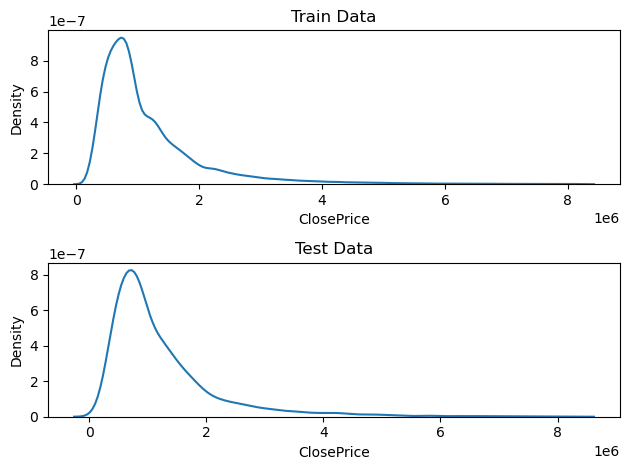

In [250]:
fig, ax = plt.subplots(2, 1)
sns.kdeplot(data=y_train, ax=ax[0])
ax[0].set_title('Train Data')
sns.kdeplot(data=y_test, ax=ax[1])
ax[1].set_title('Test Data')
plt.tight_layout()

## Decision Tree

In [246]:
# train and evaluate decision tree regressor model
dt = DecisionTreeRegressor(random_state=123)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

dt_metrics = metrics(y_test, dt_pred)

print(dt_metrics)

{'R2': '0.7700', 'MAE': '$229750.90', 'RMSE': '$467413.64', 'MedianAbsoluteError': '$100000.00', 'MDAPE': '10.71%'}


## Random Forest

In [247]:
# train and evaluate random forest model
rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=123, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_metrics = metrics(y_test, rf_pred)

print(rf_metrics)

{'R2': '0.8425', 'MAE': '$210082.44', 'RMSE': '$386840.01', 'MedianAbsoluteError': '$105350.04', 'MDAPE': '11.20%'}


## Comparison With Baseline (Linear Regression)

In [244]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

lr_metrics = metrics(y_test, lr_pred)

print(lr_metrics)

{'R2': '0.7710', 'MAE': '$285079.05', 'RMSE': '$466404.36', 'MedianAbsoluteError': '$183143.09', 'MDAPE': '19.08%'}


## Test models with encode_loc=False

In [254]:
noloc_df = preprocessing(encode_loc=False)

X = 30
X_train_noloc, X_test_noloc, y_train_noloc, y_test_noloc = train_test_split(noloc_df, X)

In [257]:
# linear regression
lr_noloc = LinearRegression()
lr_noloc.fit(X_train_noloc, y_train_noloc)
lr_noloc_pred = lr_noloc.predict(X_test_noloc)

lr_noloc_metrics = metrics(y_test_noloc, lr_noloc_pred)

In [258]:
# decision tree
dt_noloc = DecisionTreeRegressor(random_state=123)
dt_noloc.fit(X_train_noloc, y_train_noloc)
dt_noloc_pred = dt_noloc.predict(X_test_noloc)

dt_noloc_metrics = metrics(y_test_noloc, dt_noloc_pred)

In [259]:
# random forest
rf_noloc = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=123, n_jobs=-1)
rf_noloc.fit(X_train_noloc, y_train_noloc)
rf_noloc_pred = rf_noloc.predict(X_test_noloc)

rf_noloc_metrics = metrics(y_test_noloc, rf_noloc_pred)

In [260]:
results = pd.DataFrame(
    [lr_metrics, dt_metrics, rf_metrics, lr_noloc_metrics, dt_noloc_metrics, rf_noloc_metrics],
    index = ['Linear Regression',
             'Decision Tree',
             'Random Forest',
             'Linear Regression (No Location Encoding)',
             'Decision Tree (No Location Encoding)',
             'Random Forest (No Location Encoding)']
)

results

,R2,MAE,RMSE,MedianAbsoluteError,MDAPE
Linear Regression,0.7710,$285079.05,$466404.36,$183143.09,19.08%
Decision Tree,0.7700,$229750.90,$467413.64,$100000.00,10.71%
Random Forest,0.8425,$210082.44,$386840.01,$105350.04,11.20%
Linear Regression (No Location Encoding),0.3386,$515402.76,$1363385.76,$323764.86,32.02%
Decision Tree (No Location Encoding),0.2873,$292465.07,$1415304.35,$100000.00,11.11%
Random Forest (No Location Encoding),0.0135,$290433.48,$1665099.19,$111592.96,11.77%
